<a href="https://colab.research.google.com/github/ahasanulhossain07-del/Deep-Learning-Book/blob/main/Copy_of_Midterm_Exam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 👗 Smart Fashion AI with Neural Networks (Mid Term)

**Total Marks: 100 (Theory: 10 | Practical: 90)**  


---

**Instructions:**
1. Enter your course email in the cell below.
2. Read the story and problem descriptions carefully.
3. Complete the code in cells containing `# YOUR CODE HERE`. Do not modify the test cells.
4. Run all cells sequentially to ensure your tests pass before submitting.
5. Have fun!

In [1]:
# Enter your course email here
student_email = "ahasanulhossain07@gmail.com" # Example: "your.name@university.edu"

---

## 📖 Story: StyleAI — Smart Fashion Recognition

You've just joined **StyleAI**, a startup building an AI-powered wardrobe assistant app. The app lets users snap a photo of any clothing item and instantly classifies it. Your job is to build the **image classification model** that powers this feature.

The dataset is **Fashion-MNIST** — 28×28 grayscale images of 10 clothing categories:

| Label | Class Name |
|-------|------------|
| 0 | T-shirt/top |
| 1 | Trouser |
| 2 | Pullover |
| 3 | Dress |
| 4 | Coat |
| 5 | Sandal |
| 6 | Shirt |
| 7 | Sneaker |
| 8 | Bag |
| 9 | Ankle boot |


---

## Question 1: Theory (10 Marks)

### Part A (3 Marks)
Explain the difference between **Sigmoid** and **ReLU** activation functions. Why is ReLU preferred in hidden layers of deep networks? What problem does Sigmoid cause during backpropagation in deep networks?

### Part B (4 Marks)
In the context of **Gradient Descent**:
- What is the difference between **Batch Gradient Descent**, **Stochastic Gradient Descent (SGD)**, and **Mini-batch Gradient Descent**?
- State one advantage and one disadvantage of each.
- Which type would you recommend for training on Fashion-MNIST (60,000 images), and why?

### Part C (3 Marks)
In our Fashion-MNIST problem (10 classes):
1. Why do we use `nn.CrossEntropyLoss` instead of `nn.BCELoss`?
2. Why should we **NOT** put `nn.Softmax` as the last layer when using `nn.CrossEntropyLoss`?
3. What does `loss.backward()` do?

*Double-click here to write your answers*

**Part A Answer:**
Sigmoid and ReLU are both activation functions used in neural networks, but they behave differently.

# Sigmoid:
1.f(x)=1/1+e−x

2.Output is between 0 and 1

3.Smooth curve

4.More commonly used in the output layer for binary classification

# ReLU:
1.f(x)=max(0,x)

2.Output is 0 or positive value

3.Simple piecewise function

4.Commonly used in hidden layers

# Why is ReLU preferred in hidden layers:

ReLU is preferred because its calculation is very simple and, for positive values, its gradient is 1. This helps the gradient flow through many layers during backpropagation. It also makes training deep neural networks faster compared to using Sigmoid in every hidden layer.

#What problem does Sigmoid cause during backpropagation:

The main problem is the vanishing gradient problem. When the input to Sigmoid is very large or very small, its derivative becomes close to 0. During backpropagation, gradients are multiplied through many layers. If these gradients are repeatedly multiplied by very small values, they become extremely small.
As a result, the earlier layers learn very slowly or may almost stop learning. This makes training deep networks difficult.



**Part B Answer:**

Gradient Descent is an optimization method used to update the model's weights so that the loss becomes smaller. The main difference between Batch, SGD, and Mini-batch Gradient Descent is how many training samples are used to calculate the gradient before updating the weights.

# Batch Gradient Descent:

For Fashion-MNIST, Batch Gradient Descent would use all 60,000 images to calculate the gradient and then update the weights.

Advantage: The gradient is more stable because it is calculated using the complete dataset.

Disadvantage: It can be slow and needs more memory when the dataset is large.

# Stochastic Gradient Descent (SGD):

SGD takes one image at a time, calculates the loss and gradient, and immediately updates the model's weights.

Advantage: It uses less memory and can start updating the model very quickly.

Disadvantage: Because each update is based on only one image, the updates can be noisy and the loss can fluctuate.

# Mini-batch Gradient Descent:

Mini-batch Gradient Descent divides the dataset into smaller groups, such as 32, 64, or 128 images. The model calculates the gradient for one batch and then updates the weights.

Advantage: It provides a good balance between the stable updates of Batch Gradient Descent and the speed of SGD.

Disadvantage: We have to choose an appropriate batch size, and a poor choice can affect training speed and performance.

# Which one is best for Fashion-MNIST:

 Mini-batch Gradient Descent for Fashion-MNIST is best because the dataset contains 60,000 images. Using all 60,000 images for every update would be inefficient, while using only one image at a time would make the updates too noisy.

A batch size such as 32 or 64 allows the model to train efficiently while keeping the gradient reasonably stable. This is also the commonly used approach when training neural networks on image datasets.



**Part C Answer:**

# Why do we use nn.CrossEntropyLoss instead of nn.BCELoss:

Fashion-MNIST has 10 different classes, so this is a multi-class classification problem. For this type of problem, nn.CrossEntropyLoss is suitable because it directly works with multiple classes and expects the model to output a score  for each class.

nn.BCELoss is mainly used for binary classification, where the output is usually a single probability, such as 0 or 1.

# Why should we NOT put nn.Softmax as the last layer when using nn.CrossEntropyLoss:

We should not add nn.Softmax before nn.CrossEntropyLoss because CrossEntropyLoss already applies the required softmax operation internally.If we apply Softmax ourselves first, it is unnecessary and can make the numerical calculation less stable.

# What does loss.backward() do:

loss.backward() performs backpropagation.

It calculates the gradient of the loss with respect to all model parameters that have requires_grad=True.


---

## Question 2: Load & Explore the Data (15 Marks)

### 2.1 Download the Dataset (1 Marks)

We will use `torchvision.datasets.FashionMNIST` to download the dataset. This is similar to how we loaded data from `.npy` files in class, but here PyTorch handles the download for us.

Run the cell below to download the training and test sets:

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torchvision
import numpy as np
import matplotlib.pyplot as plt

# Class names for Fashion-MNIST
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Download Fashion-MNIST — this downloads the data into a ./data folder
# download=True means it will download if not already present
full_train_dataset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True)
test_dataset_raw = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True)

train_images_all = full_train_dataset.data.numpy()  # shape: (60000, 28, 28)
train_labels_all = full_train_dataset.targets.numpy()  # shape: (60000,)
test_images_all = test_dataset_raw.data.numpy()
test_labels_all = test_dataset_raw.targets.numpy()

print(f"Training set size: {len(full_train_dataset)}")
print(f"Test set size: {len(test_dataset_raw)}")
print(f"Image shape: {full_train_dataset[0][0].size}")

100%|██████████| 26.4M/26.4M [00:01<00:00, 19.2MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 303kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.64MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 24.2MB/s]

Training set size: 60000
Test set size: 10000
Image shape: (28, 28)


### 2.2 Visualize Sample Images (5 Marks)

Create a **2×5 subplot figure** (figsize 12×5) showing one sample image from **each of the 10 classes**.
- Display each image in grayscale (`cmap='gray'`)
- Title each subplot with its class name
- Turn off axis ticks

*Hint: loop through classes 0-9, find one sample of each class, and plot it.*

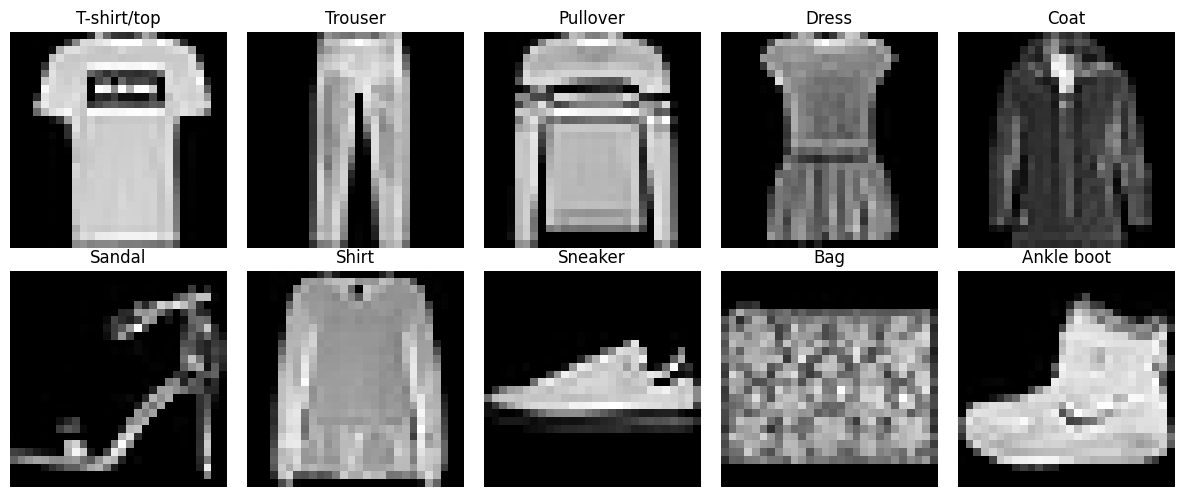

In [6]:

plt.figure(figsize=(12, 5))

for i in range(10):
    class_images = train_images_all[train_labels_all == i]
    sample_image = class_images[0]

    plt.subplot(2, 5, i + 1)
    plt.imshow(sample_image, cmap='gray')
    plt.title(class_names[i])
    plt.axis('off')

plt.tight_layout()
plt.show()


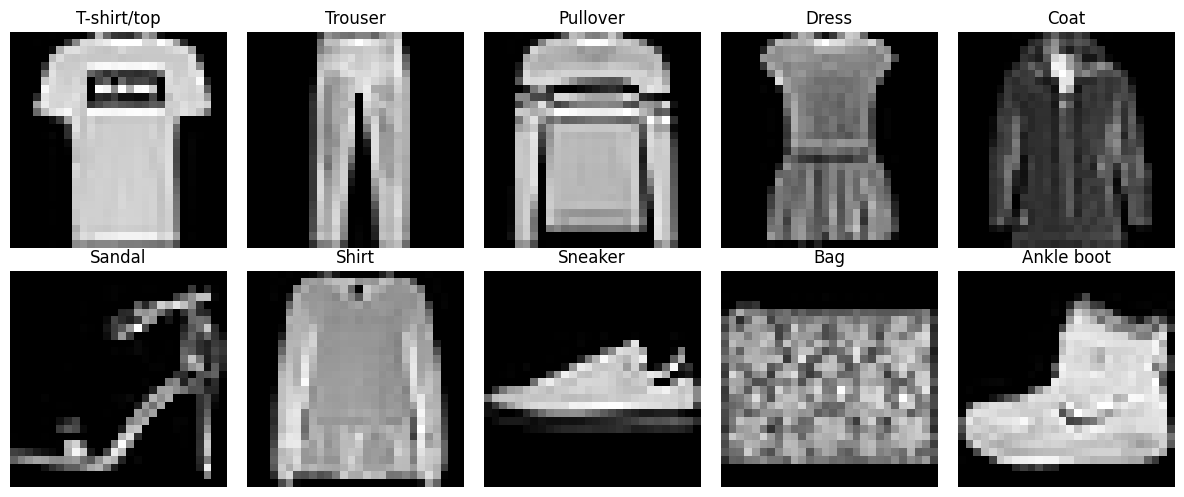

### 2.3 Class Distribution (5 Marks)

Plot a **bar chart** showing how many samples belong to each class in the training set.
- X-axis: class names
- Y-axis: count
- Title: "Training Set Class Distribution"
- Add the count number on top of each bar

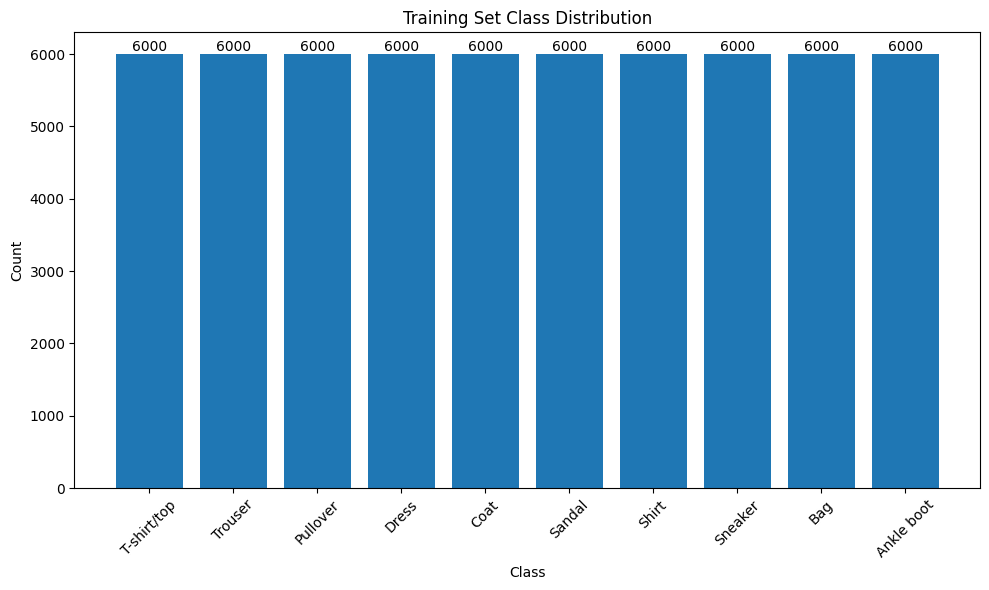

In [10]:

class_counts=[]
for i in range(10):
  count=np.sum(train_labels_all==i)
  class_counts.append(count)

plt.figure(figsize=(10,6))
bars=plt.bar(class_names,class_counts)
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Training Set Class Distribution')
plt.xticks(rotation=45)
for bar in bars:
  plt.text(
      bar.get_x()+bar.get_width()/2,
      bar.get_height(),
      str(int(bar.get_height())),
      ha='center',
      va='bottom'

  )
plt.tight_layout()
plt.show()

### 2.4 Prepare Tensors and Split (4 Marks)

Now we need to extract the data as NumPy arrays, normalize it, split it, and convert to PyTorch tensors.



**Your tasks:**
1. Normalize pixel values to **[0, 1]** by dividing by 255.0.
2. Split training data into **train (50,000)** and **validation (10,000)** using `train_test_split` with `random_state=42`.
3. Convert all sets to PyTorch tensors — images as `float32`, labels as `long`.

**Required variables:** `X_train, X_val, X_test` (tensors), `y_train, y_val, y_test` (tensors)

In [11]:
from sklearn.model_selection import train_test_split


X=train_images_all/255.0
X_test=test_images_all/255.0

X_train, X_val, y_train, y_val = train_test_split(
    X, train_labels_all,
    test_size=10000,
    random_state=42
)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_val = torch.tensor(y_val, dtype=torch.long)
y_test = torch.tensor(test_labels_all, dtype=torch.long)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

X_train: torch.Size([50000, 28, 28])
X_val: torch.Size([10000, 28, 28])
X_test: torch.Size([10000, 28, 28])


In [12]:
# --- TEST CELL (DO NOT MODIFY) ---
assert X_train.shape == (50000, 28, 28), f"Expected X_train shape (50000, 28, 28), got {X_train.shape}"
assert X_val.shape == (10000, 28, 28), f"Expected X_val shape (10000, 28, 28), got {X_val.shape}"
assert X_train.dtype == torch.float32, "X_train should be float32"
assert y_train.dtype == torch.long, "y_train should be long"
assert X_train.max() <= 1.0 and X_train.min() >= 0.0, "Pixel values should be in [0, 1]"
print("✅ Q2.4 Passed!")
print(f"   Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

✅ Q2.4 Passed!
   Train: torch.Size([50000, 28, 28]), Val: torch.Size([10000, 28, 28]), Test: torch.Size([10000, 28, 28])


---

## Question 3: Build DataLoaders (10 Marks)

Create `TensorDataset` and `DataLoader` objects for the train, validation, and test sets.

- **batch_size = 64**
- **shuffle = True** for training, **False** for validation and test

**Required variables:** `train_loader`, `val_loader`, `test_loader`

In [14]:

batch_size=64
train_dataset=TensorDataset(X_train,y_train)
val_dataset=TensorDataset(X_val,y_val)
test_dataset=TensorDataset(X_test,y_test)

train_loader=DataLoader(train_dataset,batch_size=batch_size,shuffle=True)
val_loader=DataLoader(val_dataset,batch_size=batch_size,shuffle=False)
test_loader=DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 782
Validation batches: 157
Test batches: 157


In [15]:
# --- TEST CELL (DO NOT MODIFY) ---
batch_X, batch_y = next(iter(train_loader))
assert batch_X.shape == (64, 28, 28), f"Batch shape should be (64, 28, 28), got {batch_X.shape}"
assert batch_y.dtype == torch.long, "Labels should be torch.long"
assert batch_X.max() <= 1.0, "Images should be normalized"
print("✅ Q3 Passed!")
print(f"   Batch images shape: {batch_X.shape}")
print(f"   Batch labels shape: {batch_y.shape}")

✅ Q3 Passed!
   Batch images shape: torch.Size([64, 28, 28])
   Batch labels shape: torch.Size([64])


---

## Question 4: Define the Model (15 Marks)

Create a class `FashionClassifier` inheriting from `nn.Module`.

Use `nn.Sequential` with this architecture:

| Layer | Description |
|-------|-------------|
| Flatten | Convert 28×28 → 784 |
| Linear | 784 → 256 |
| ReLU | Activation |
| Linear | 256 → 128 |
| ReLU | Activation |
| Linear | 128 → 64 |
| ReLU | Activation |
| Linear | 64 → 10 |

> **Note**: Do NOT apply Softmax at the output layer.

After defining the class:
1. Create an instance of `FashionClassifier`.
2. Print the model architecture.

In [18]:

class FashionClassifier(nn.Module):
  def __init__(self):
    super().__init__()

    self.model=nn.Sequential(
        nn.Flatten(),
        nn.Linear(28*28,256),
        nn.ReLU(),
        nn.Linear(256,128),
        nn.ReLU(),
        nn.Linear(128,64),
        nn.ReLU(),
        nn.Linear(64,10)
    )

  def forward(self,x):
    return self.model(x)

model=FashionClassifier()
print(model)

FashionClassifier(
  (model): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=64, bias=True)
    (6): ReLU()
    (7): Linear(in_features=64, out_features=10, bias=True)
  )
)


In [19]:
# --- TEST CELL (DO NOT MODIFY) ---
test_input = torch.randn(5, 28, 28)
test_output = model(test_input)
assert test_output.shape == (5, 10), f"Output shape should be (5, 10), got {test_output.shape}"
total_params = sum(p.numel() for p in model.parameters())
assert total_params > 0, "Model should have trainable parameters"
print("✅ Q4 Passed!")
print(f"   Total parameters: {total_params}")
print(model)

✅ Q4 Passed!
   Total parameters: 242762
FashionClassifier(
  (model): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=64, bias=True)
    (6): ReLU()
    (7): Linear(in_features=64, out_features=10, bias=True)
  )
)


---

## Question 5: Train the Model (25 Marks)

### 5.1 Set Up Training (5 Marks)
- Loss function: `nn.CrossEntropyLoss`
- Optimizer: `optim.SGD` with `lr=0.01`
- Number of epochs: **15**

In [21]:
# YOUR CODE HERE
criterion=nn.CrossEntropyLoss()
optimizer=optim.SGD(model.parameters(),lr=0.01)
epochs=15

### 5.2 Training Loop (15 Marks)

Write a complete training loop for **15 epochs**.

For each epoch:
- Train on `train_loader` and compute training loss
- Evaluate on `val_loader` (with `torch.no_grad()`) and compute validation loss
- Print: `Epoch {epoch+1}/{epochs} | Train Loss: {:.4f} | Val Loss: {:.4f} `

Store: `train_losses`, `val_losses`, (lists, one value per epoch).

In [24]:
train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

for epoch in range(epochs):

    # Training
    model.train()
    train_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = train_loss / len(train_loader)
    train_accuracy = 100 * correct / total

    # Validation
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss = val_loss / len(val_loader)
    val_accuracy = 100 * correct / total

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

Epoch 1/15 | Train Loss: 0.3910 | Val Loss: 0.4815
Epoch 2/15 | Train Loss: 0.3842 | Val Loss: 0.4568
Epoch 3/15 | Train Loss: 0.3756 | Val Loss: 0.4000
Epoch 4/15 | Train Loss: 0.3698 | Val Loss: 0.3988
Epoch 5/15 | Train Loss: 0.3621 | Val Loss: 0.4270
Epoch 6/15 | Train Loss: 0.3556 | Val Loss: 0.3997
Epoch 7/15 | Train Loss: 0.3506 | Val Loss: 0.3868
Epoch 8/15 | Train Loss: 0.3442 | Val Loss: 0.3666
Epoch 9/15 | Train Loss: 0.3382 | Val Loss: 0.3909
Epoch 10/15 | Train Loss: 0.3332 | Val Loss: 0.4247
Epoch 11/15 | Train Loss: 0.3289 | Val Loss: 0.3898
Epoch 12/15 | Train Loss: 0.3229 | Val Loss: 0.3986
Epoch 13/15 | Train Loss: 0.3190 | Val Loss: 0.3626
Epoch 14/15 | Train Loss: 0.3128 | Val Loss: 0.3780
Epoch 15/15 | Train Loss: 0.3094 | Val Loss: 0.3528


In [25]:
# --- TEST CELL (DO NOT MODIFY) ---
assert len(train_losses) == 15, f"Expected 15 epochs, got {len(train_losses)}"
assert len(val_losses) == 15
assert train_losses[-1] < train_losses[0], "Training loss should decrease"
print("✅ Q5.2 Passed!")
print(f"   Final Train Acc: {train_accuracies[-1]:.2f}%, Final Val Acc: {val_accuracies[-1]:.2f}%")

✅ Q5.2 Passed!
   Final Train Acc: 88.95%, Final Val Acc: 87.40%


### 5.3 Test Evaluation (5 Marks)

Evaluate the model on the **test set**. Print the test_accuracy (required_variable)

Also, collect all test predictions and true labels into lists called `all_preds` and `all_labels` (we'll use them for analysis later).

Print: `Test Accuracy: {:.2f}%`

In [26]:

model.eval()

all_preds = []
all_labels = []

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.tolist())
        all_labels.extend(labels.tolist())

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = 100 * correct / total

print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 86.78%


In [27]:
# --- TEST CELL (DO NOT MODIFY) ---
assert test_accuracy > 40.0, f"Test accuracy should be > 40%, got {test_accuracy:.2f}%"
assert len(all_preds) == len(X_test), "Predictions should cover all test samples"
print(f"✅ Q5.3 Passed! Test Accuracy: {test_accuracy:.2f}%")

✅ Q5.3 Passed! Test Accuracy: 86.78%


---

## Question 6: Visualize & Analyze Results (25 Marks)

### 6.1 Plot Training Loss vs Validation Loss (5 Marks)

Plot **Training Loss** and **Validation Loss** on the same figure across epochs.
- Include a legend, title ("Loss Curve"), and axis labels.

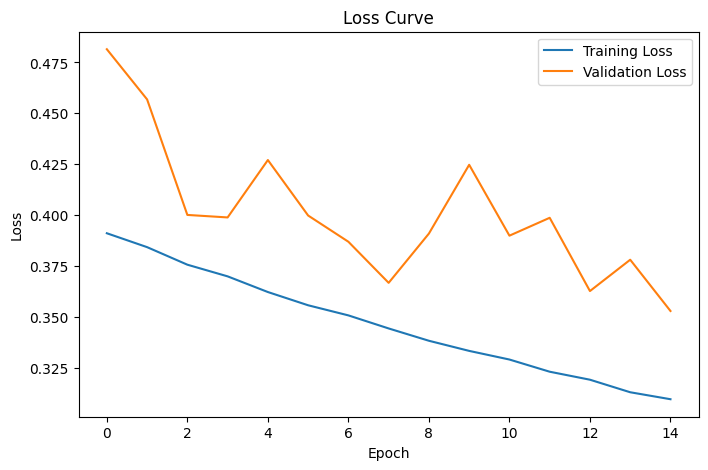

In [28]:

plt.figure(figsize=(8, 5))

plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()

plt.show()

### 6.2 Plot Training Accuracy vs Validation Accuracy (5 Marks)

Plot **Training Accuracy** and **Validation Accuracy** on the same figure across epochs.
- Include a legend, title ("Accuracy Curve"), and axis labels.

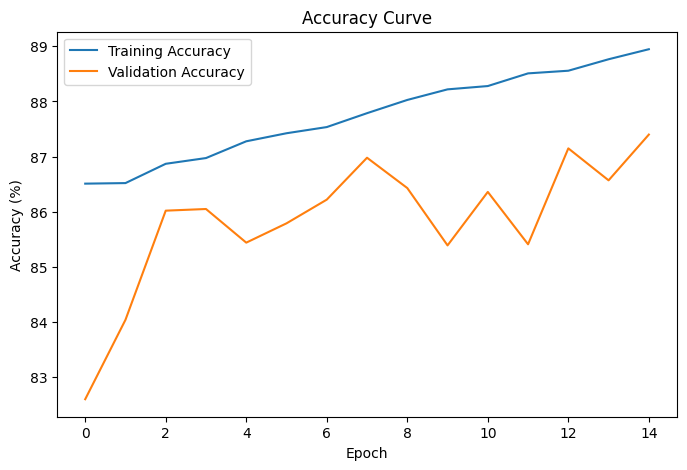

In [29]:

plt.figure(figsize=(8, 5))

plt.plot(train_accuracies, label='Training Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy Curve')
plt.legend()

plt.show()

### 6.3 Confusion Matrix (5 Marks)

Using `sklearn.metrics`:
1. Compute the confusion matrix on test predictions.
2. Display it as a heatmap using `ConfusionMatrixDisplay` with `class_names` as labels.
3. Title: "StyleAI Fashion Classifier — Test Confusion Matrix"

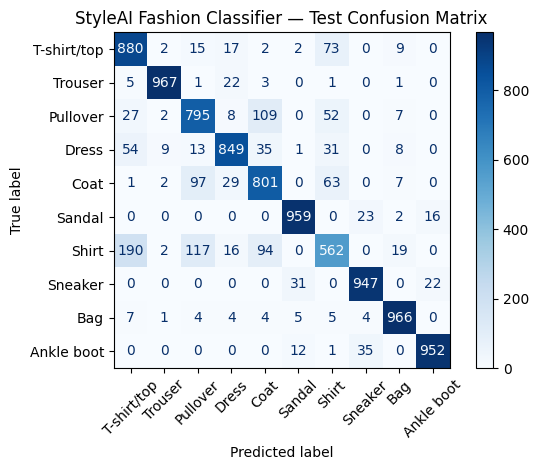

In [30]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay



cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(cmap='Blues', xticks_rotation=45)

plt.title('StyleAI Fashion Classifier — Test Confusion Matrix')
plt.tight_layout()
plt.show()

### 6.4 Classification Report (5 Marks)

Print the `classification_report` from sklearn using `target_names=class_names`.

In [31]:
from sklearn.metrics import classification_report


print(classification_report(all_labels, all_preds, target_names=class_names))

              precision    recall  f1-score   support

 T-shirt/top       0.76      0.88      0.81      1000
     Trouser       0.98      0.97      0.97      1000
    Pullover       0.76      0.80      0.78      1000
       Dress       0.90      0.85      0.87      1000
        Coat       0.76      0.80      0.78      1000
      Sandal       0.95      0.96      0.95      1000
       Shirt       0.71      0.56      0.63      1000
     Sneaker       0.94      0.95      0.94      1000
         Bag       0.95      0.97      0.96      1000
  Ankle boot       0.96      0.95      0.96      1000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



### 6.5 Written Analysis (5 Marks)

In the markdown cell below, answer:
1. Which two classes are **most often confused** with each other? Look at the confusion matrix and explain **why** (think about visual similarity).
2. Is the model **overfitting or underfitting**? How can you tell from the learning curves?

*Double-click here to write your analysis*

**Your Analysis:**

# Most confused classes:
The two classes that are most often confused are Shirt and T-shirt/top. Both classes have a similar shape and appearance, especially around the upper part of the clothes and sleeves. Because Fashion-MNIST images are small (28×28) and grayscale, some important details are not very clear, so the model can sometimes confuse these two classes.

# Overfitting or underfitting:
The model shows some signs of overfitting if the training accuracy becomes higher than the validation accuracy and the validation loss stops decreasing or starts increasing. This means the model is learning the training images very well but is not improving as much on unseen validation images. However, if both training and validation accuracy are still improving together and their gap is small, then the model is not strongly overfitting.